In [34]:
import sys
print(sys.executable)

/Users/manaskolaskar/Developer/Projects/fifa-worldcup-intelligence-hub/.venv/bin/python3.13


In [35]:
import pandas as pd

players = pd.read_csv('../data/players.csv')
appearances = pd.read_csv('../data/appearances.csv')
games = pd.read_csv('../data/games.csv')

print("Players:", players.shape)
print("Appearances:", appearances.shape)
print("Games:", games.shape)

Players: (47669, 26)
Appearances: (1884051, 13)
Games: (88665, 23)


In [36]:
print("Players columns:")
print(players.columns.tolist())

print("\nAppearances columns:")
print(appearances.columns.tolist())

print("\nGames columns:")
print(games.columns.tolist())

Players columns:
['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']

Appearances columns:
['appearance_id', 'game_id', 'player_id', 'player_club_id', 'player_current_club_id', 'date', 'player_name', 'competition_id', 'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played']

Games columns:
['game_id', 'competition_id', 'season', 'round', 'date', 'home_club_id', 'away_club_id', 'home_club_goals', 'away_club_goals', 'home_club_position', 'away_club_position', 'home_club_manager_name', 'away_club_manager_name', 'stadium', 'attendance', 'referee', 'url', 'home

In [37]:
players.head(3)

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0


In [38]:
## Building a Player Summary Table

In [39]:
player_stats = (
    appearances
    .groupby('player_id')
    .agg({
        'goals': 'sum',
        'assists': 'sum',
        'minutes_played': 'sum',
        'yellow_cards': 'sum',
        'red_cards': 'sum',
        'game_id': 'count'
    })
    .reset_index()
)

player_stats.rename(columns={
    'game_id': 'matches_played'
}, inplace=True)

player_stats.head()

,player_id,goals,assists,minutes_played,yellow_cards,red_cards,matches_played
0,10,48,25,8808,19,0,136
1,26,0,0,13508,4,2,152
2,65,38,13,8788,11,1,122
3,77,0,0,307,0,0,4
4,80,0,0,1080,0,0,12


In [40]:
player_summary = player_stats.merge(
    players[[
        'player_id',
        'name',
        'position',
        'image_url',
        'sub_position',
        'country_of_citizenship',
        'market_value_in_eur',
        'highest_market_value_in_eur',
        'international_caps',
        'international_goals'
    ]],
    on='player_id',
    how='left'
)

player_summary.head()

,player_id,goals,assists,minutes_played,yellow_cards,red_cards,matches_played,name,position,image_url,sub_position,country_of_citizenship,market_value_in_eur,highest_market_value_in_eur,international_caps,international_goals
0,10,48,25,8808,19,0,136,Miroslav Klose,Attack,https://img.a.transfermarkt.technology/portrai...,Centre-Forward,Germany,1000000.0,30000000.0,NaN,NaN
1,26,0,0,13508,4,2,152,Roman Weidenfeller,Goalkeeper,https://img.a.transfermarkt.technology/portrai...,Goalkeeper,Germany,750000.0,8000000.0,NaN,NaN
2,65,38,13,8788,11,1,122,Dimitar Berbatov,Attack,https://img.a.transfermarkt.technology/portrai...,Centre-Forward,Bulgaria,1000000.0,34500000.0,NaN,NaN
3,77,0,0,307,0,0,4,Lúcio,Defender,https://img.a.transfermarkt.technology/portrai...,Centre-Back,Brazil,200000.0,24500000.0,NaN,NaN
4,80,0,0,1080,0,0,12,Tom Starke,Goalkeeper,https://img.a.transfermarkt.technology/portrai...,Goalkeeper,Germany,100000.0,3000000.0,NaN,NaN


In [41]:
player_summary.shape

(28713, 16)

In [42]:
player_summary.head(5)

,player_id,goals,assists,minutes_played,yellow_cards,red_cards,matches_played,name,position,image_url,sub_position,country_of_citizenship,market_value_in_eur,highest_market_value_in_eur,international_caps,international_goals
0,10,48,25,8808,19,0,136,Miroslav Klose,Attack,https://img.a.transfermarkt.technology/portrai...,Centre-Forward,Germany,1000000.0,30000000.0,NaN,NaN
1,26,0,0,13508,4,2,152,Roman Weidenfeller,Goalkeeper,https://img.a.transfermarkt.technology/portrai...,Goalkeeper,Germany,750000.0,8000000.0,NaN,NaN
2,65,38,13,8788,11,1,122,Dimitar Berbatov,Attack,https://img.a.transfermarkt.technology/portrai...,Centre-Forward,Bulgaria,1000000.0,34500000.0,NaN,NaN
3,77,0,0,307,0,0,4,Lúcio,Defender,https://img.a.transfermarkt.technology/portrai...,Centre-Back,Brazil,200000.0,24500000.0,NaN,NaN
4,80,0,0,1080,0,0,12,Tom Starke,Goalkeeper,https://img.a.transfermarkt.technology/portrai...,Goalkeeper,Germany,100000.0,3000000.0,NaN,NaN


In [43]:
## Feature Engineeing

In [44]:
player_summary['goals_per_90'] = (
    player_summary['goals'] /
    player_summary['minutes_played']
) * 90

player_summary['assists_per_90'] = (
    player_summary['assists'] /
    player_summary['minutes_played']
) * 90

player_summary['cards_per_90'] = (
    (player_summary['yellow_cards'] + player_summary['red_cards']) /
    player_summary['minutes_played']
) * 90

player_summary['minutes_per_match'] = (
    player_summary['minutes_played'] /
    player_summary['matches_played']
)

In [45]:
player_summary = player_summary[
    player_summary['minutes_played'] >= 900
].copy()

player_summary = player_summary.fillna(0)

player_summary.shape

(17459, 20)

In [46]:
features = [
    'goals_per_90',
    'assists_per_90',
    'cards_per_90',
    'minutes_per_match',
    'market_value_in_eur',
    'international_caps'
]

X = player_summary[features]

X.head()

,goals_per_90,assists_per_90,cards_per_90,minutes_per_match,market_value_in_eur,international_caps
0,0.490463,0.255450,0.194142,64.764706,1000000.0,0.0
1,0.000000,0.000000,0.039976,88.868421,750000.0,0.0
2,0.389167,0.133136,0.122895,72.032787,1000000.0,0.0
4,0.000000,0.000000,0.000000,90.000000,100000.0,0.0
5,0.025112,0.050223,0.100446,87.414634,400000.0,0.0


In [47]:
## Scaling Features


In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 2.7146067 ,  1.94246708, -0.08632038, -0.2031977 , -0.21392097,
        -0.38675623],
       [-0.8519391 , -1.04574014, -1.39807753,  1.40692529, -0.24291168,
        -0.38675623],
       [ 1.97800217,  0.51166395, -0.69254301,  0.28230855, -0.21392097,
        -0.38675623],
       [-0.8519391 , -1.04574014, -1.73822661,  1.48251452, -0.31828751,
        -0.38675623],
       [-0.66933275, -0.45823725, -0.88355144,  1.30981263, -0.28349866,
        -0.38675623]])

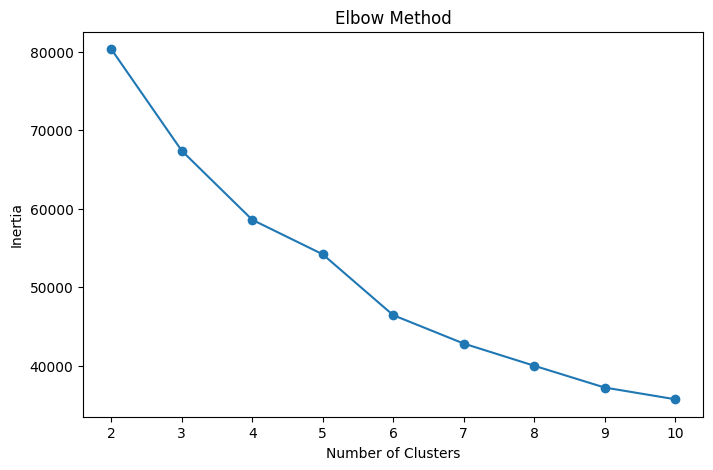

In [49]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.show()

In [50]:
# Train Final K-Means Model

In [51]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42
)

player_summary['cluster'] = kmeans.fit_predict(X_scaled)

player_summary[['name', 'position', 'cluster']].head(10)

,name,position,cluster
0,Miroslav Klose,Attack,1
1,Roman Weidenfeller,Goalkeeper,0
2,Dimitar Berbatov,Attack,1
4,Tom Starke,Goalkeeper,0
5,Dedê,Defender,0
7,Tomas Rosicky,Midfield,5
8,Roque Santa Cruz,Attack,1
9,Gerald Asamoah,Attack,5
10,Tamás Hajnal,Midfield,5
12,Sérgio da Silva Pinto,Midfield,4


In [52]:
player_summary['cluster'].value_counts()

cluster
0    5551
5    4109
4    3666
1    2951
2     799
3     383
Name: count, dtype: int64

In [53]:
cluster_profiles = (
    player_summary
    .groupby('cluster')[features]
    .mean()
)

cluster_profiles

,goals_per_90,assists_per_90,cards_per_90,minutes_per_match,market_value_in_eur,international_caps
cluster,,,,,,
0,0.030689,0.033392,0.142574,81.448741,1.473937e+06,2.696811
1,0.342341,0.181104,0.181096,57.151225,2.607508e+06,4.947475
2,0.149410,0.118834,0.181519,71.412186,5.173917e+06,69.231539
3,0.221871,0.162990,0.175337,67.590625,4.732898e+07,23.796345
4,0.056379,0.051586,0.359823,68.793641,1.226043e+06,2.385161
5,0.110440,0.120341,0.172669,55.467785,1.711867e+06,3.093210


In [54]:
cluster_names = {
    0: "Defensive / Goalkeeper",
    1: "Attackers",
    2: "International Veterans",
    3: "Elite Stars",
    4: "Aggressive Defenders",
    5: "Utility Midfielders"
}

player_summary["cluster_name"] = player_summary["cluster"].map(cluster_names)

player_summary[["name", "position", "cluster", "cluster_name"]].head(10)

,name,position,cluster,cluster_name
0,Miroslav Klose,Attack,1,Attackers
1,Roman Weidenfeller,Goalkeeper,0,Defensive / Goalkeeper
2,Dimitar Berbatov,Attack,1,Attackers
4,Tom Starke,Goalkeeper,0,Defensive / Goalkeeper
5,Dedê,Defender,0,Defensive / Goalkeeper
7,Tomas Rosicky,Midfield,5,Utility Midfielders
8,Roque Santa Cruz,Attack,1,Attackers
9,Gerald Asamoah,Attack,5,Utility Midfielders
10,Tamás Hajnal,Midfield,5,Utility Midfielders
12,Sérgio da Silva Pinto,Midfield,4,Aggressive Defenders


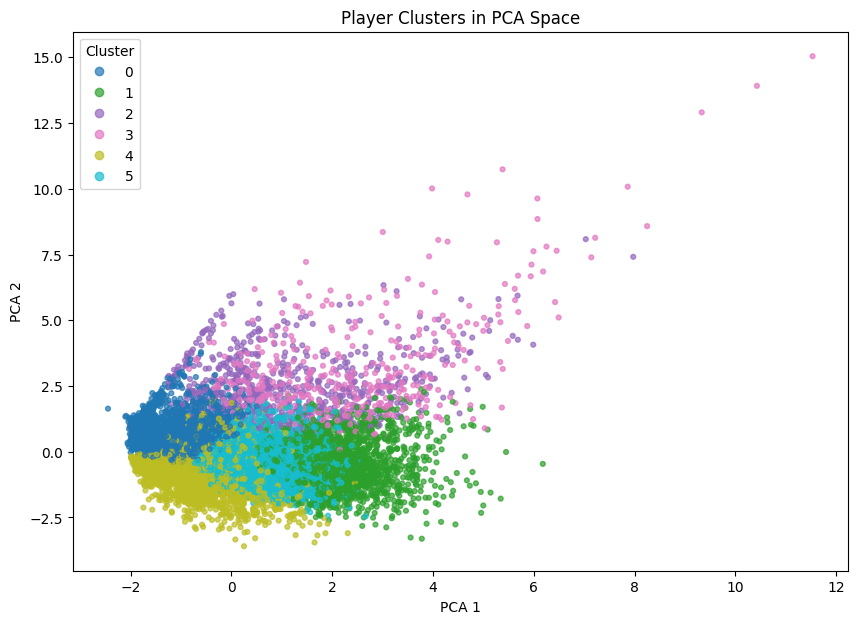

In [55]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

player_summary["pca_1"] = X_pca[:, 0]
player_summary["pca_2"] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    player_summary["pca_1"],
    player_summary["pca_2"],
    c=player_summary["cluster"],
    cmap="tab10",
    s=12,
    alpha=0.7
)
plt.title("Player Clusters in PCA Space")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

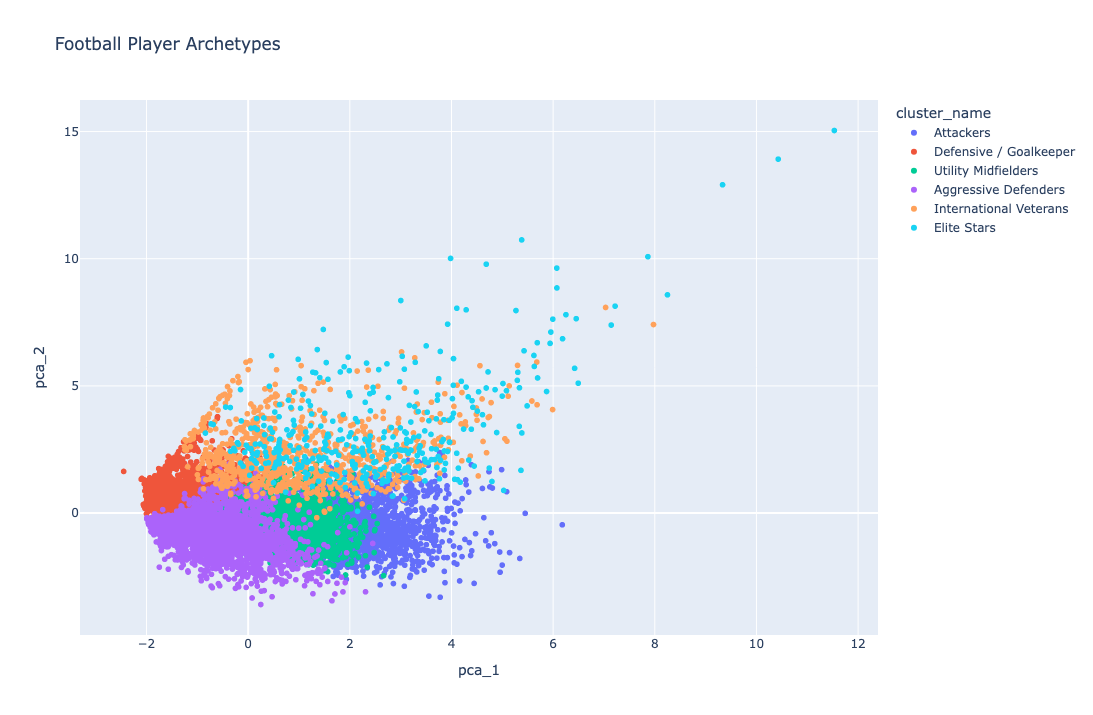

In [56]:
import plotly.express as px

fig = px.scatter(
    player_summary,
    x="pca_1",
    y="pca_2",
    color="cluster_name",
    hover_data=[
        "name",
        "position",
        "market_value_in_eur",
        "goals_per_90",
        "assists_per_90"
    ],
    title="Football Player Archetypes",
    width=1100,
    height=700
)

fig.show()

In [57]:
player_summary[
    player_summary["name"].str.contains(
        "Messi",
        case=False,
        na=False
    )
][[
    "name",
    "position",
    "cluster_name",
    "market_value_in_eur",
    "goals_per_90",
    "assists_per_90"
]].head()

,name,position,cluster_name,market_value_in_eur,goals_per_90,assists_per_90
2262,Lionel Messi,Attack,International Veterans,15000000.0,0.909253,0.450603
19626,Junior Messias,Attack,Utility Midfielders,1200000.0,0.249846,0.111043


In [58]:
player_summary.to_csv(
    "../data/player_clusters.csv",
    index=False
)